# **בדיקת חיבור לשרת ומעבד**

In [1]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU'))) # המשך רק אם התקבל 1 או יותר

2026-03-22 16:20:50.040585: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 16:20:50.401525: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-22 16:20:50.401554: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-22 16:20:50.401575: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-22 16:20:50.427406: I tensorflow/core/platform/cpu_feature_g

TensorFlow Version: 2.14.0
Num GPUs Available:  1


# **ייבוא ספריות**

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("All libraries loaded successfully!")

All libraries loaded successfully!


# **נתיבים והגדרות**

In [3]:
# --- הגדרת נתיבים חדשים (מצביעים לתיקייה בשרת של רופין) ---
BASE_DIR = "/users/amit.cohen/Final_Dataset_Split"
TRAIN_DIR = os.path.join(BASE_DIR, 'train') # נתיב ל-70% מהתמונות
VAL_DIR = os.path.join(BASE_DIR, 'val')     # נתיב ל-15% מהתמונות
TEST_DIR = os.path.join(BASE_DIR, 'test')   # נתיב ל-15% הנותרים

# --- פרמטרים ---
IMG_SIZE = (224, 224) # תבנית שהרשת מצפה לקבל (VGG16 הוגדרה לגודל הזה)

# תטען לזיכרון 32 תמונות, תעביר את כולן ברשת במקביל,
# תחשב את הטעות הממוצעת של כולן, ורק אז תעדכן את המשקולות.
BATCH_SIZE = 32

# **חלוקה לגנרטורים - אימון \ אימות**

In [4]:
# גנרטור לאימון (עם אוגמנטציה)

# === הגדרת הגנרטורים והאוגמנטציה (Data Augmentation) ===
# המטרה: מניעת Overfitting (שינון) ע"י יצירת וריאציות של התמונות "תוך כדי תנועה" (On-the-fly).
# בכל Epoch, הגנרטור מחליף את התמונה המקורית בגרסה מעובדת, כך שהמודל לעולם לא רואה את אותה תמונה פעמיים בדיוק.

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,           # עיוות מינימלי
    zoom_range=0.05,            # זום מינימלי למניעת חיתוך
    horizontal_flip=True,
    fill_mode='nearest'
)

# גנרטור לוולידציה (בלי אוגמנטציה, רק rescale)
val_datagen = ImageDataGenerator(rescale=1./255)

# טעינה
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, # נתיב ישיר לתיקיית ה-Train
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=True # כדי למנוע מהמודל ללמוד את סדר הנתונים ולהבטיח גיוון בכל באץ
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR, # נתיב ישיר לתיקיית ה-Val
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    shuffle=False
)

class_names = list(train_gen.class_indices.keys())
print(f"המחלקות שזוהו: {class_names}")

Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.
המחלקות שזוהו: ['Black&White', 'Cartoon', 'Good', 'Multiple', 'Noise or blur', 'Sketch', 'Text', 'Toys']


# **Grid Search using keras-tuner**

ONLY 8 COMBINATIONS -> run on home pc

Trial 8 Complete [00h 03m 04s]
val_accuracy: 0.8333333134651184

Best val_accuracy So Far: 0.8541666865348816
Total elapsed time: 00h 24m 51s

HPO Search Completed! Best Configuration:
Units: 256 | Dropout: 0.2 | LR: 0.0001

Generating Top 5 History Graph...


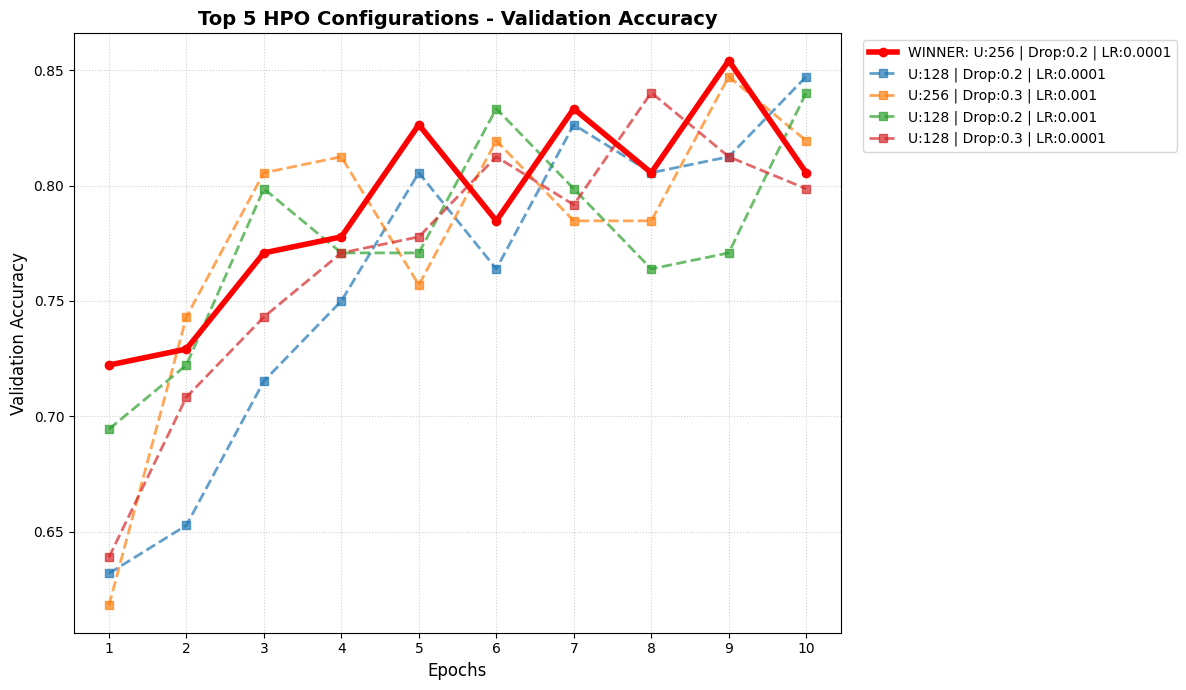

In [ ]:
!pip install keras-tuner -q

import keras_tuner as kt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("=========================================")
print("Starting Focused Grid Search HPO (8 Configurations)")
print("=========================================\n")

# מילון גלובלי שישמור את היסטוריית האיפוקים באופן ודאי
all_histories = {}

class CustomHyperModel(kt.HyperModel):
    def build(self, hp):
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False

        model = Sequential()
        model.add(base_model)
        model.add(Flatten())

        # צמצמנו ל-2 אפשרויות בכל פרמטר (סה"כ 2x2x2 = 8 ריצות)
        hp_units = hp.Choice('units', values=[128, 256])
        model.add(Dense(units=hp_units, activation='relu'))

        hp_dropout = hp.Choice('dropout', values=[0.2, 0.3])
        model.add(Dropout(rate=hp_dropout))

        model.add(Dense(8, activation='softmax'))

        hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])

        model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    def fit(self, hp, model, *args, **kwargs):
        history = model.fit(*args, **kwargs)

        u = hp.get('units')
        d = hp.get('dropout')
        lr = hp.get('learning_rate')
        label_name = f"U:{u} | Drop:{d} | LR:{lr}"

        # לכידה ושמירה ידנית של הנתונים ברגע שהאימון מסתיים
        if 'val_accuracy' in history.history:
            all_histories[label_name] = history.history['val_accuracy']

        return history

tuner = kt.GridSearch(
    hypermodel=CustomHyperModel(),
    objective='val_accuracy',
    max_trials=8,
    directory='vgg16_hpo_fast',
    project_name='custom_head_fast',
    overwrite=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("--- Starting Search ---")
tuner.search(
    x=train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_u = best_hps.get('units')
best_d = best_hps.get('dropout')
best_lr = best_hps.get('learning_rate')
best_label = f"U:{best_u} | Drop:{best_d} | LR:{best_lr}"

print("\n" + "="*50)
print("HPO Search Completed! Best Configuration:")
print(f"Units: {best_u} | Dropout: {best_d} | LR: {best_lr}")
print("="*50 + "\n")

print("Generating Top 5 History Graph...")

# מיון ושליפת 5 התוצאות הטובות ביותר מהמילון שלנו
sorted_histories = sorted(all_histories.items(), key=lambda x: max(x[1]), reverse=True)
top_5_histories = sorted_histories[:5]

plt.figure(figsize=(12, 7))

for label, val_acc_list in top_5_histories:
    x_epochs = range(1, len(val_acc_list) + 1)

    if label == best_label:
        plt.plot(x_epochs, val_acc_list, marker='o', linewidth=4, color='red', label=f"WINNER: {label}", zorder=10)
    else:
        plt.plot(x_epochs, val_acc_list, marker='s', linewidth=2, linestyle='--', alpha=0.7, label=label)

plt.title('Top 5 HPO Configurations - Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# **Grid Search using keras-tuner for SERVER**

Trial 128 Complete [00h 02m 27s]
val_accuracy: 0.8888888955116272

Best val_accuracy So Far: 0.9166666865348816
Total elapsed time: 07h 27m 24s

SERVER HPO Search Completed! Best Configuration:
1. Batch Size: 32
2. Dense Units: 256
3. Dropout Rate: 0.5
4. Learning Rate: 0.0001

Generating Advanced HPO Comparison Graph...

Saving plot to disk as 'server_hpo_results.png'...
Plot successfully saved!


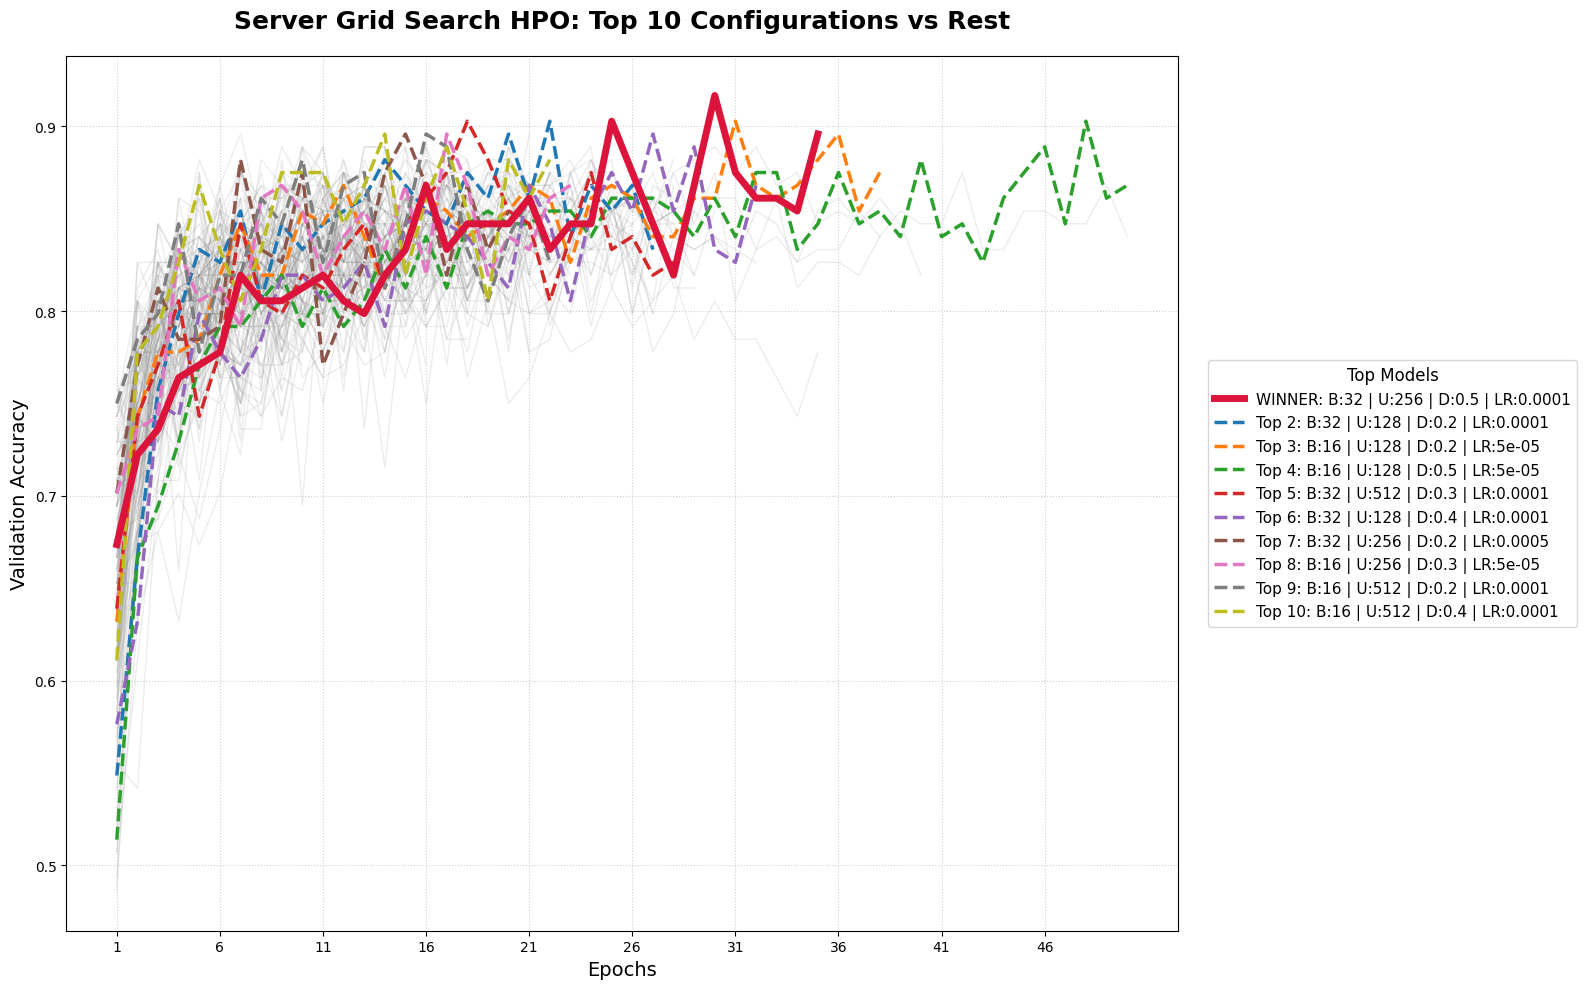


Best Model Architecture Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 256)               6422784   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 8)                 2056      
                                                                 
Total params: 21139528 (80.64 MB)
Trainable params: 6424840 (24.51 MB)
Non-trainable params: 14714688 (56.13 MB)
_________________________________________

In [ ]:
# התקנת הספריה (חובה להריץ פעם אחת בסביבה כמו Colab/Server)
!pip install keras-tuner -q

# פקודת קסם לתצוגת גרפים (חשוב במיוחד אם השרת מריץ Jupyter Notebook)
%matplotlib inline

import keras_tuner as kt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Starting SERVER-GRADE Grid Search HPO (Including Batch Size & Manual History Tracking)...")

# מילון גלובלי לשמירת היסטוריית האיפוקים המלאה לכל 128 הריצות
all_histories = {}

# 1. יצירת מחלקה מותאמת אישית של HyperModel
class VGG16HyperModel(kt.HyperModel):
    def build(self, hp):
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = False

        model = Sequential()
        model.add(base_model)
        model.add(Flatten()) # השטחה רגילה

        # --- היפר-פרמטר 1: מספר הנוירונים בשכבה הנסתרת ---
        hp_units = hp.Choice('units', values=[128, 256, 512, 1024])
        model.add(Dense(units=hp_units, activation='relu'))

        # --- היפר-פרמטר 2: אחוז ה-Dropout ---
        hp_dropout = hp.Choice('dropout', values=[0.2, 0.3, 0.4, 0.5])
        model.add(Dropout(rate=hp_dropout))

        # שכבת הפלט קבועה בהתאם למשימה (8 מחלקות)
        model.add(Dense(8, activation='softmax'))

        # --- היפר-פרמטר 3: קצב הלמידה של האופטימייזר ---
        hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4, 5e-5])

        model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    # פונקציה מיוחדת שמתערבת רגע לפני כל אימון
    def fit(self, hp, model, *args, **kwargs):
        # --- היפר-פרמטר 4: גודל אצווה (Batch Size) ---
        hp_batch_size = hp.Choice('batch_size', values=[16, 32]) # 64 ו-128 ירדו עקב שגיאת ריצה וחוסר זיכרון ב-GPU

        # עדכון ה-batch_size של הגנרטור סט האימון
        if 'x' in kwargs:
            kwargs['x'].batch_size = hp_batch_size
        elif len(args) > 0:
            args[0].batch_size = hp_batch_size

        # עדכון ה-batch_size של הגנרטור סט האימות
        if 'validation_data' in kwargs:
            kwargs['validation_data'].batch_size = hp_batch_size

        # הפעלת האימון ושמירת התוצאה
        history = model.fit(*args, **kwargs)

        # --- מנגנון שמירת ההיסטוריה הידני ---
        u = hp.get('units')
        d = hp.get('dropout')
        lr = hp.get('learning_rate')
        label_name = f"B:{hp_batch_size} | U:{u} | D:{d} | LR:{lr}"

        if 'val_accuracy' in history.history:
            all_histories[label_name] = history.history['val_accuracy']

        return history

# 2. אתחול מנוע הסריקה (128 קומבינציות סך הכל)
tuner = kt.GridSearch(
    hypermodel=VGG16HyperModel(),
    objective='val_accuracy',
    max_trials=128, # מעודכן ל-128
    directory='vgg16_server_hpo_logs',
    project_name='custom_head_batch_tuning',
    overwrite=True # מתחיל סריקה נקייה מההתחלה כדי למנוע שאריות של הריצה שקרסה
)

# 3. מנגנון עצירה מוקדמת (5 איפוקים סבלנות למודלים עמוקים)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 4. הרצת הסריקה המסיבית
print("\n--- Starting Massive Server Search ---")
tuner.search(
    x=train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

# 5. חילוץ והדפסת התוצאות הסופיות
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print("\n=========================================")
print("SERVER HPO Search Completed! Best Configuration:")
print(f"1. Batch Size: {best_hps.get('batch_size')}")
print(f"2. Dense Units: {best_hps.get('units')}")
print(f"3. Dropout Rate: {best_hps.get('dropout')}")
print(f"4. Learning Rate: {best_hps.get('learning_rate')}")
print("=========================================")

# 6. ציור הגרף (10 המובילים מהמילון, השאר מטושטשים ברקע)
print("\nGenerating Advanced HPO Comparison Graph...")

plt.figure(figsize=(16, 10))

# מיון כל ההיסטוריות ששמרנו לפי הדיוק המקסימלי שהושג
sorted_histories = sorted(all_histories.items(), key=lambda x: max(x[1]), reverse=True)

# מעבר על כל הריצות וציור הקווים
for i, (label, val_acc_list) in enumerate(sorted_histories):
    x_epochs = range(1, len(val_acc_list) + 1)

    if i == 0:
        # מקום ראשון - קו מנצח (אדום בולט)
        plt.plot(x_epochs, val_acc_list, linewidth=5, linestyle='-', color='crimson', label=f"WINNER: {label}", zorder=20)
    elif i < 10:
        # מקומות 2 עד 10
        plt.plot(x_epochs, val_acc_list, linewidth=2.5, linestyle='--', label=f"Top {i+1}: {label}", zorder=10)
    else:
        # כל השאר (118 הריצות הנותרות - רקע אפור שקוף)
        plt.plot(x_epochs, val_acc_list, linewidth=1, color='gray', alpha=0.15, zorder=1)

plt.title('Server Grid Search HPO: Top 10 Configurations vs Rest', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Validation Accuracy', fontsize=14)

# סידור השנתות בציר ה-X כדי שיהיו ברורות גם ב-50 איפוקים
plt.xticks(range(1, 51, 5))

plt.legend(fontsize=11, loc='center left', bbox_to_anchor=(1.02, 0.5), title="Top Models", title_fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# ==========================================
# רשת הביטחון: שמירת הגרף כקובץ תמונה ברזולוציה גבוהה!
# ==========================================
print("\nSaving plot to disk as 'server_hpo_results.png'...")
plt.savefig('server_hpo_results.png', dpi=300, bbox_inches='tight')
print("Plot successfully saved!")

# ניסיון להציג למסך
try:
    plt.show()
except Exception as e:
    print(f"Could not display plot on screen. Error: {e}")

# סיכום של המודל המנצח
print("\nBest Model Architecture Summary:")
best_model.summary()
print("\nSaving the best model to disk...")
best_model.save('server_best_vgg16_model.keras')
print("Model saved successfully as 'server_best_vgg16_model.keras'!")

# **5 K-Fold Cross-Validation for SERVER**

Preparing for 5-Fold Cross Validation...
Total images collected for K-Fold: 816

--- Starting 5-Fold Cross Validation ---

Processing Fold 1/5...
Found 652 validated image filenames belonging to 8 classes.
Found 164 validated image filenames belonging to 8 classes.


2026-03-18 09:07:58.796892: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 35319 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:37:00.0, compute capability: 8.0


Epoch 1/35


2026-03-18 09:08:02.159299: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-03-18 09:08:02.860206: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-18 09:08:04.042525: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-18 09:08:04.703721: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f71128ab980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-18 09:08:04.703746: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-03-18 09:08:04.710135: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-18 09:08:04.828025: I ./tensorflow/compiler/jit/device_compil

21/21 [==============================] - 15s 504ms/step - loss: 1.8085 - accuracy: 0.3344 - val_loss: 1.2227 - val_accuracy: 0.5610
Epoch 2/35
21/21 [==============================] - 9s 448ms/step - loss: 1.2181 - accuracy: 0.5583 - val_loss: 1.0017 - val_accuracy: 0.5976
Epoch 3/35
21/21 [==============================] - 9s 443ms/step - loss: 0.9527 - accuracy: 0.6672 - val_loss: 0.8530 - val_accuracy: 0.6768
Epoch 4/35
21/21 [==============================] - 9s 451ms/step - loss: 0.7902 - accuracy: 0.7393 - val_loss: 0.6871 - val_accuracy: 0.7988
Epoch 5/35
21/21 [==============================] - 10s 460ms/step - loss: 0.6740 - accuracy: 0.7653 - val_loss: 0.6367 - val_accuracy: 0.8110
Epoch 6/35
21/21 [==============================] - 9s 450ms/step - loss: 0.6558 - accuracy: 0.7791 - val_loss: 0.6724 - val_accuracy: 0.7561
Epoch 7/35
21/21 [==============================] - 9s 449ms/step - loss: 0.5398 - accuracy: 0.8359 - val_loss: 0.6022 - val_accuracy: 0.8049
Epoch 8/35
21/2

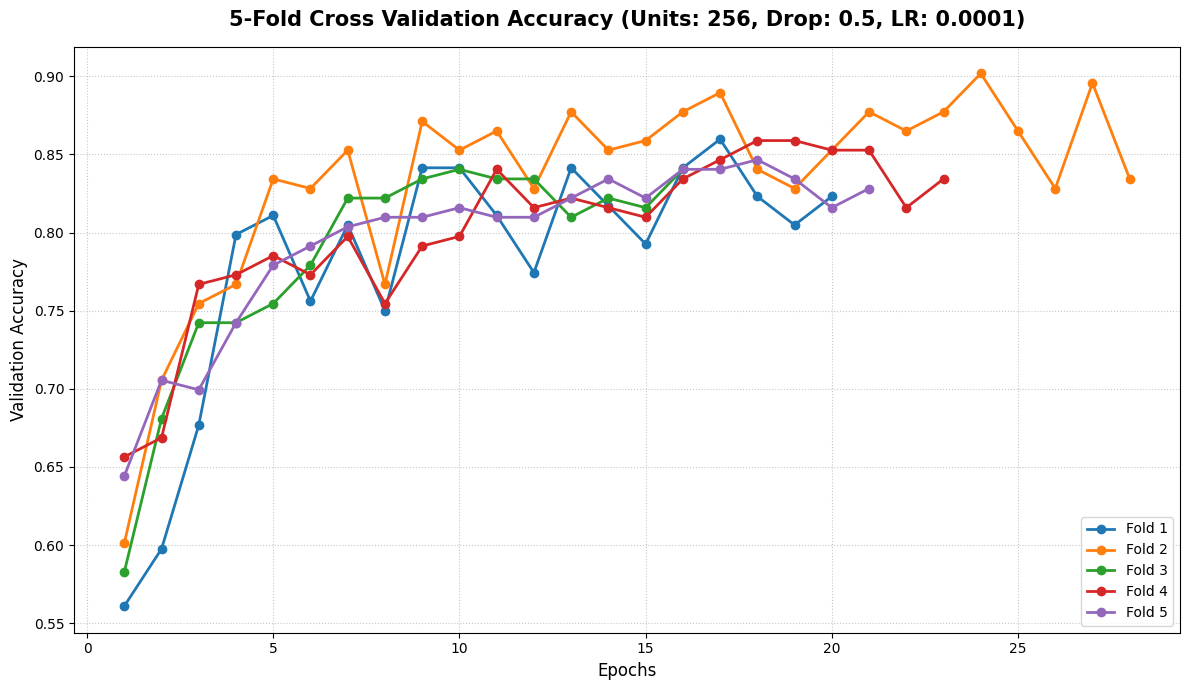

In [ ]:
# התקנת הספריות הנדרשות לשרת (חובה להריץ פעם אחת)
!pip install pandas scikit-learn -q

import pandas as pd
from sklearn.model_selection import StratifiedKFold

# פקודת קסם לתצוגה דרך ממשק Colab
%matplotlib inline

print("Preparing for 5-Fold Cross Validation...")

# ==========================================
# 1. Winning Parameters from HPO
# ==========================================
BEST_UNITS = 256
BEST_DROPOUT = 0.5
BEST_LR = 1e-4
BEST_BATCH_SIZE = 32
EPOCHS_PER_FOLD = 35 # עצר שם בHPO

# רשימה לשמירת הגרפים של כל הקיפולים
all_histories = []

# ==========================================
# 2. Data Preparation (Train + Val)
# ==========================================
def create_dataframe(directories):
    filepaths = []
    labels = []
    for directory in directories:
        for class_name in os.listdir(directory):
            class_dir = os.path.join(directory, class_name)
            if os.path.isdir(class_dir):
                for img_file in os.listdir(class_dir):
                    filepaths.append(os.path.join(class_dir, img_file))
                    labels.append(class_name)
    return pd.DataFrame({'filename': filepaths, 'class': labels})

df = create_dataframe([TRAIN_DIR, VAL_DIR])
print(f"Total images collected for K-Fold: {len(df)}")

# ==========================================
# 3. Model Builder Function
# ==========================================
def build_best_model():
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = Sequential()
    model.add(base_model)
    model.add(Flatten())

    model.add(Dense(BEST_UNITS, activation='relu'))
    model.add(Dropout(BEST_DROPOUT))
    model.add(Dense(8, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=BEST_LR),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ==========================================
# 4. K-Fold Loop
# ==========================================
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

fold_accuracies = []

print(f"\n--- Starting {k}-Fold Cross Validation ---")

for fold, (train_idx, val_idx) in enumerate(skf.split(df['filename'], df['class'])):
    print(f"\nProcessing Fold {fold + 1}/{k}...")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    # אוגמנטציות כפי שהוגדרו מראש
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.05,
        zoom_range=0.05,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    val_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df, x_col='filename', y_col='class',
        target_size=(224, 224), batch_size=BEST_BATCH_SIZE,
        class_mode='sparse', shuffle=True
    )

    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_df, x_col='filename', y_col='class',
        target_size=(224, 224), batch_size=BEST_BATCH_SIZE,
        class_mode='sparse', shuffle=False
    )

    model = build_best_model()

    early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PER_FOLD,
        callbacks=[early_stop],
        verbose=1
    )

    best_val_acc = max(history.history['val_accuracy'])
    fold_accuracies.append(best_val_acc)
    all_histories.append(history.history['val_accuracy'])

    print(f"Fold {fold + 1} Best Validation Accuracy: {best_val_acc:.4f}")

# ==========================================
# 5. Statistics
# ==========================================
mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)

print("\n=========================================")
print("K-Fold Cross Validation Results")
print("=========================================")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1}: {acc:.4f}")
print(f"-----------------------------------------")
print(f"Mean Accuracy : {mean_acc:.4f}")
print(f"Std Deviation : +/-{std_acc:.4f}")
print("=========================================")

# ==========================================
# 6. Plotting and Saving
# ==========================================
print("\nGenerating Epoch-by-Epoch K-Fold Learning Curves...")

plt.figure(figsize=(12, 7))

for i, val_acc in enumerate(all_histories):
    x_epochs = range(1, len(val_acc) + 1)
    plt.plot(x_epochs, val_acc, marker='o', linewidth=2, label=f'Fold {i+1}')

plt.title(f'{k}-Fold Cross Validation Accuracy (Units: {BEST_UNITS}, Drop: {BEST_DROPOUT}, LR: {BEST_LR})', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()

print("Saving plot to disk as 'server_kfold_results.png'...")
plt.savefig('server_kfold_results.png', dpi=300, bbox_inches='tight')

try:
    plt.show()
except Exception as e:
    print(f"Plot saved but could not display on screen: {e}")

# **אימון סופי וגרפים וויזואליים**

Selected Final Configuration: Units=256, Dropout=0.5, LR=0.0001

Starting training for the final model...
Epoch 1/25
21/21 [==============================] - ETA: 0s - loss: 1.8346 - accuracy: 0.3571
Epoch 1: val_accuracy improved from -inf to 0.56944, saving model to final_best_vgg16_model.h5


/users/amit.cohen/.local/lib/python3.9/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


21/21 [==============================] - 11s 472ms/step - loss: 1.8346 - accuracy: 0.3571 - val_loss: 1.2828 - val_accuracy: 0.5694
Epoch 2/25
21/21 [==============================] - ETA: 0s - loss: 1.1580 - accuracy: 0.6012
Epoch 2: val_accuracy improved from 0.56944 to 0.69444, saving model to final_best_vgg16_model.h5
21/21 [==============================] - 10s 484ms/step - loss: 1.1580 - accuracy: 0.6012 - val_loss: 0.8900 - val_accuracy: 0.6944
Epoch 3/25
21/21 [==============================] - ETA: 0s - loss: 0.8737 - accuracy: 0.7009
Epoch 3: val_accuracy improved from 0.69444 to 0.79861, saving model to final_best_vgg16_model.h5
21/21 [==============================] - 10s 485ms/step - loss: 0.8737 - accuracy: 0.7009 - val_loss: 0.7081 - val_accuracy: 0.7986
Epoch 4/25
21/21 [==============================] - ETA: 0s - loss: 0.7587 - accuracy: 0.7485
Epoch 4: val_accuracy did not improve from 0.79861
21/21 [==============================] - 10s 466ms/step - loss: 0.7587 - ac

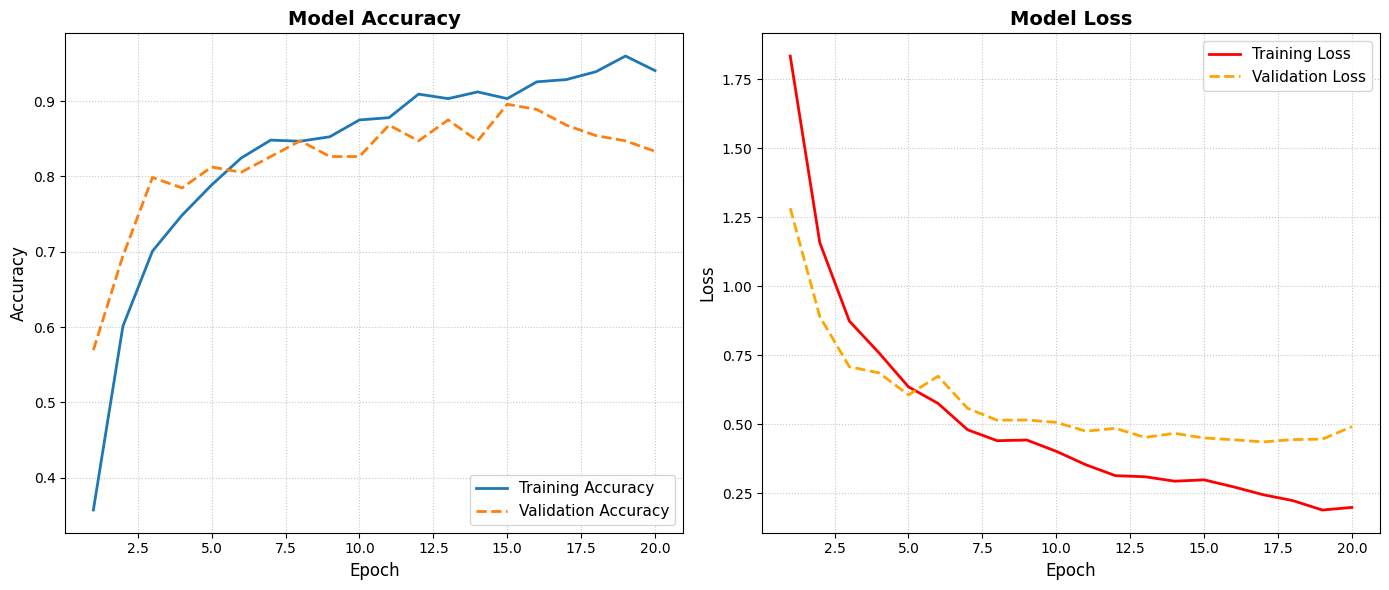

In [6]:
# 1. הגדרת הפרמטרים למודל הסופי הנבחר מה-HPO
BEST_UNITS = 256
BEST_DROPOUT = 0.5
BEST_LR = 0.0001
EPOCHS = 25

print(f"Selected Final Configuration: Units={BEST_UNITS}, Dropout={BEST_DROPOUT}, LR={BEST_LR}")

# 2. הגדרת Callbacks לניהול תהליך האימון
# EarlyStopping: מפסיק את האימון אם אין שיפור ב-Loss של הוולידציה במשך 3 אפוקים
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: שומר את המודל המוצלח ביותר ישירות על השרת (ללא דרייב)
checkpoint = ModelCheckpoint(
    "final_best_vgg16_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 3. בניית המודל - VGG16 כבסיס (Feature Extractor)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# הקפאת המשקולות של VGG16
for layer in base_model.layers:
    layer.trainable = False

# בניית שכבות הסיווג (Classification Head)
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(BEST_UNITS, activation='relu', name='final_dense_layer')(x)
x = layers.Dropout(BEST_DROPOUT)(x)

# משיכת מספר המחלקות ישירות מהגנרטור (כדי למנוע שגיאות של משתנים חסרים)
num_classes = len(train_gen.class_indices)
output_layer = layers.Dense(num_classes, activation='softmax', name='prediction')(x)

final_model = models.Model(inputs=base_model.input, outputs=output_layer, name="VGG16_FinalModel")

final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. הרצת האימון הסופי
print("\nStarting training for the final model...")
history = final_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

# 5. חילוץ התוצאות הסופיות
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])

print("\n=========================================")
print(f"Training Complete!")
print(f"Highest Validation Accuracy: {best_val_acc:.4f} ({(best_val_acc*100):.2f}%)")
print(f"Lowest Validation Loss: {best_val_loss:.4f}")
print("=========================================\n")

# 6. ציור גרפים של תהליך האימון (Accuracy & Loss) - שילוב של הקוד שלך
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1) # מתחיל מ-1 כדי שהציר ייראה טוב יותר

plt.figure(figsize=(14, 6))

# גרף דיוק (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
plt.legend(loc='lower right', fontsize=11)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# גרף הפסד (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--', color='orange')
plt.legend(loc='upper right', fontsize=11)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()

# שמירת הגרף בשרת והצגתו
plt.savefig('final_model_learning_curves.png', dpi=300)
print("\nPlot saved as 'final_model_learning_curves.png'")
plt.show()

# **הצגת מטריצות ואחוזי הצלחה**

In [9]:
!pip install seaborn scikit-learn -q

Preparing generators for evaluation (Shuffle=False)...
Found 672 images belonging to 8 classes.
Found 144 images belonging to 8 classes.

Processing predictions for: TRAIN Set...
21/21 [==============================] - 4s 192ms/step


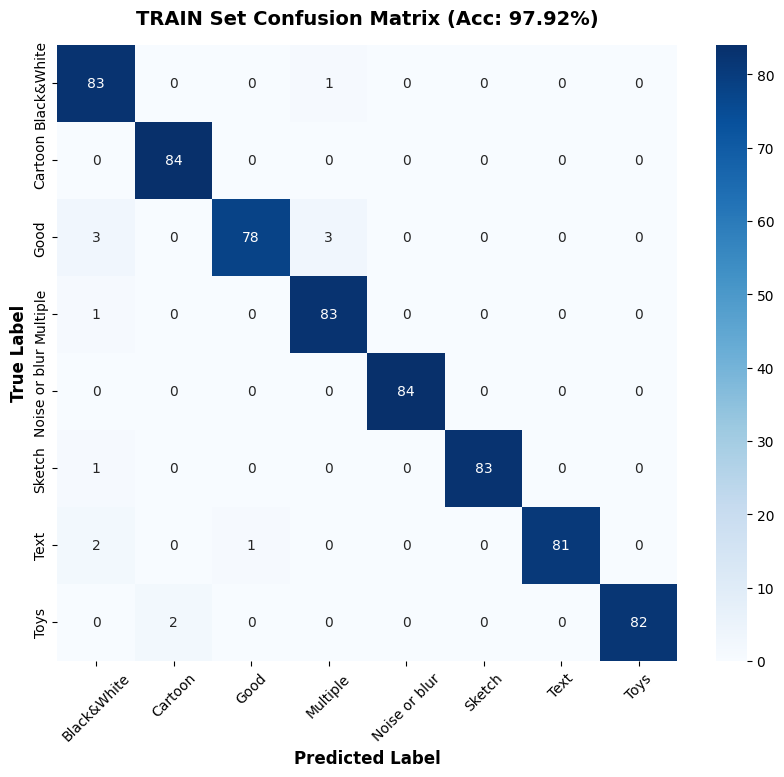


Processing predictions for: VALIDATION Set...
5/5 [==============================] - 1s 130ms/step


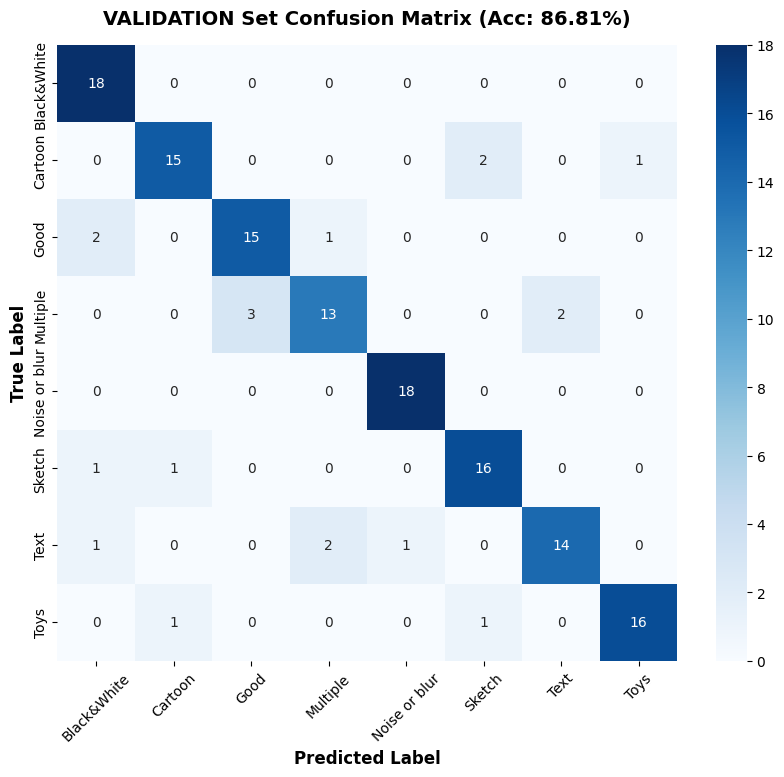


Preparing visual display of predictions...


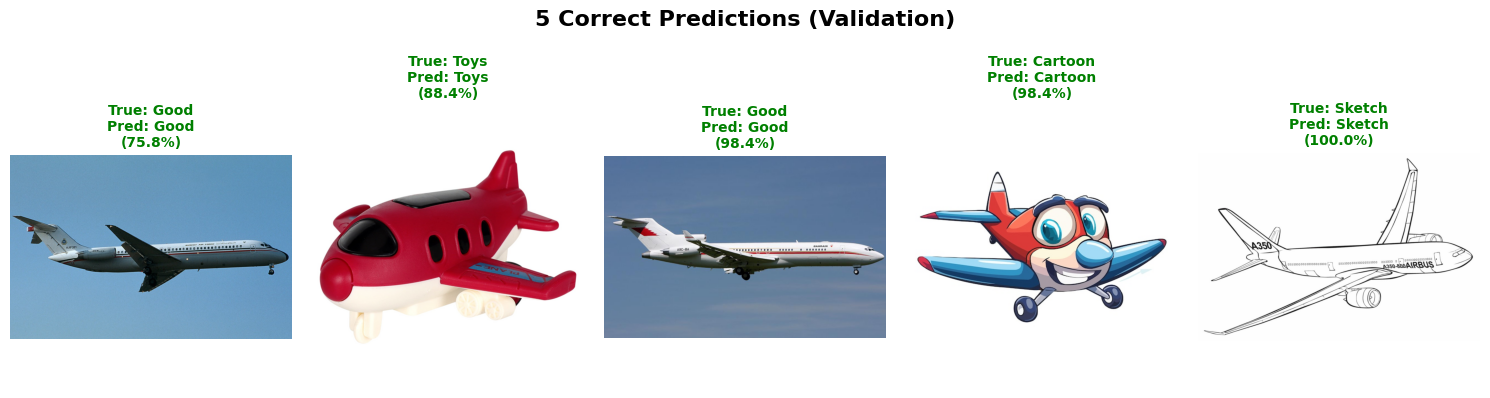

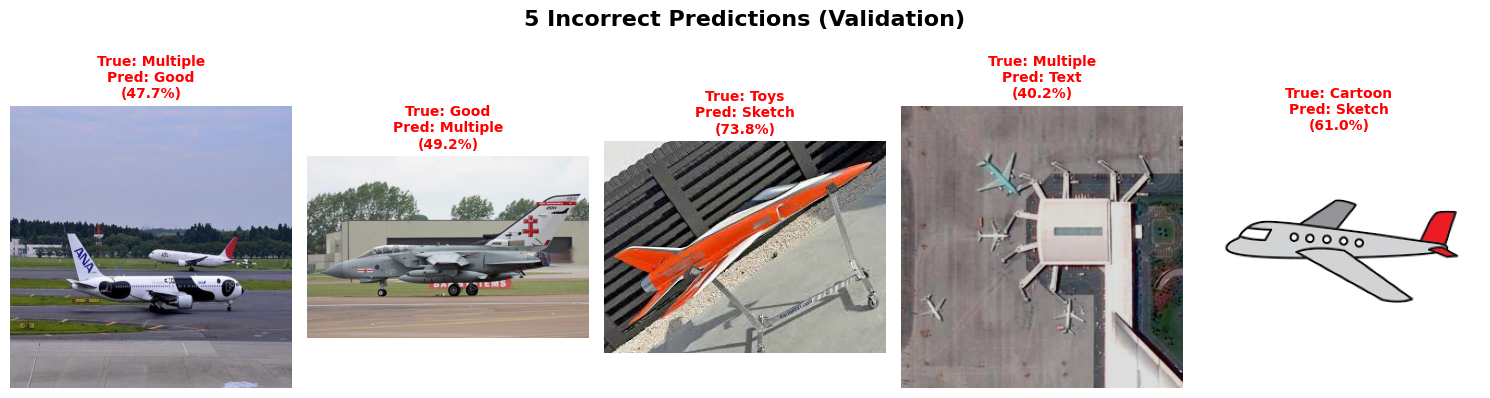

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. הכנת נתונים ללא ערבוב (חובה עבור Confusion Matrix)
print("Preparing generators for evaluation (Shuffle=False)...")

eval_datagen = ImageDataGenerator(rescale=1./255)

# גנרטור TRAIN (לבדיקת שינון)
train_gen_eval = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# גנרטור VAL (לבדיקת ביצועים)
val_gen_eval = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# שמות המחלקות
class_names = list(train_gen_eval.class_indices.keys())

# 2. פונקציה לחישוב והצגת מטריצה
def analyze_and_plot(generator, title_set):
    print(f"\nProcessing predictions for: {title_set}...")
    generator.reset()

    # חיזוי (שים לב: משתמשים ב-final_model מהבלוק הקודם)
    preds_probs = final_model.predict(generator, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)
    y_true = generator.classes

    # חישוב מטריצה ודיוק
    cm = confusion_matrix(y_true, y_pred)
    acc = np.mean(y_true == y_pred)

    # ציור היט-מאפ (Heatmap)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title_set} Confusion Matrix (Acc: {acc*100:.2f}%)', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('True Label', fontweight='bold', fontsize=12)
    plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
    plt.xticks(rotation=45)

    # שמירת המטריצה בשרת
    plt.savefig(f'confusion_matrix_{title_set.split()[0].lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    return preds_probs, y_pred, y_true

# 3. הרצת הבדיקות (מטריצות)

# א. מטריצה ל-TRAIN
train_probs, train_preds, train_true = analyze_and_plot(train_gen_eval, "TRAIN Set")

# ב. מטריצה ל-VAL (שומרים את התוצאות להצגת התמונות)
val_probs, val_preds, val_true = analyze_and_plot(val_gen_eval, "VALIDATION Set")

# 4. הצגת תמונות (הצלחות vs כישלונות ב-VAL)
print("\nPreparing visual display of predictions...")

# אינדקסים
correct_indices = np.where(val_preds == val_true)[0]
incorrect_indices = np.where(val_preds != val_true)[0]

def plot_images_from_paths(indices, generator, title, is_error=False):
    if len(indices) == 0:
        print(f"No images to display for: {title}")
        return

    n_show = min(5, len(indices))
    selected_indices = np.random.choice(indices, n_show, replace=False)

    plt.figure(figsize=(15, 4))
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.05)

    for i, idx in enumerate(selected_indices):
        # משיכת נתיב התמונה הספציפית ישירות מהגנרטור
        img_path = generator.filepaths[idx]

        # טעינת התמונה רק לצורך תצוגה
        img = plt.imread(img_path)

        true_lbl = class_names[val_true[idx]]
        pred_lbl = class_names[val_preds[idx]]
        conf = np.max(val_probs[idx]) * 100

        col = 'red' if is_error else 'green'

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"True: {true_lbl}\nPred: {pred_lbl}\n({conf:.1f}%)", color=col, fontsize=10, fontweight='bold')
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f'predictions_sample_{"error" if is_error else "correct"}.png', dpi=300, bbox_inches='tight')
    plt.show()

# הצגה
plot_images_from_paths(correct_indices, val_gen_eval, "5 Correct Predictions (Validation)", is_error=False)

if len(incorrect_indices) > 0:
    plot_images_from_paths(incorrect_indices, val_gen_eval, "5 Incorrect Predictions (Validation)", is_error=True)
else:
    print("\nModel achieved 100% accuracy on Validation set!")